In [1]:
import cogsworth
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
pops = [
    cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/qcflag-5_part{i}")
    for i in range(34)
]
for pop in pops:
    pop.initial_binaries
    pop.initial_galaxy
    pop.initC
    pop.final_bpp
    pop.bin_nums
    pop.final_pos
    pop.final_vel
    pop._file = None

pop = cogsworth.pop.concat(*pops)
# del pops

cogsworth warning: file was saved with gala v1.11.0 but you are using v1.11.1.dev18
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPot

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(



cogsworth warning: file was saved with gala v1.11.0 but you are using v1.11.1.dev18


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(



cogsworth warning: file was saved with gala v1.11.0 but you are using v1.11.1.dev18


...

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(



cogsworth warning: file was saved with gala v1.11.0 but you are using v1.11.1.dev18


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(



cogsworth warning: file was saved with gala v1.11.0 but you are using v1.11.1.dev18


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(



In [3]:
pop.bpp["row_num"] = np.arange(len(pop.bpp))
pop.colour = "tab:blue"
pop.label = "Fiducial"

# Rates

In [4]:
scale_up = 6e10 / pop.mass_binaries
scale_up

np.float64(97.18424978557164)

In [5]:
n_ns = (pop.final_bpp["kstar_1"] == 13).sum() + (pop.final_bpp["kstar_2"] == 13).sum()
n_bh = (pop.final_bpp["kstar_1"] == 14).sum() + (pop.final_bpp["kstar_2"] == 14).sum()
print(f"Rates (unscaled)\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
print(f"Rates (scaled)\n  Total: {(n_ns + n_bh) * scale_up:.1e}, NSs: {n_ns * scale_up:.1e}, BHs: {n_bh * scale_up:.1e}")

Rates (unscaled)
  Total: 6773627, NSs: 4887606, BHs: 1886021
Rates (scaled)
  Total: 6.6e+08, NSs: 4.7e+08, BHs: 1.8e+08


Olejak+20 predicted 1.2e8 BHs, close!

# Spatial distributions

In [6]:
kinematics = helpers.get_kinematics([pop])
stars = cogsworth.sfh.SandersBinney2015(
    size=n_bh + n_ns,
    **{
        "potential": gp.MilkyWayPotential(version='v2'),
        "time_bins": 5,
        "verbose": True
    }
)

Pre-computing lookback time, guiding radius and frequency interpolations
Initiating sampling procedure
  Sampling 5485545 stars from the thin_disc
    Sampling 658042 stars with lookback times between 0.00 Gyr and 2.00 Gyr
    Sampling 836889 stars with lookback times between 2.00 Gyr and 4.00 Gyr
    Sampling 1062532 stars with lookback times between 4.00 Gyr and 6.00 Gyr


    Sampling 1327307 stars with lookback times between 6.00 Gyr and 8.00 Gyr
    Sampling 1600775 stars with lookback times between 8.00 Gyr and 10.00 Gyr
  Sampling 1288082 stars from the thick_disc
    Sampling 1288082 stars with lookback times between 10.00 Gyr and 12.00 Gyr


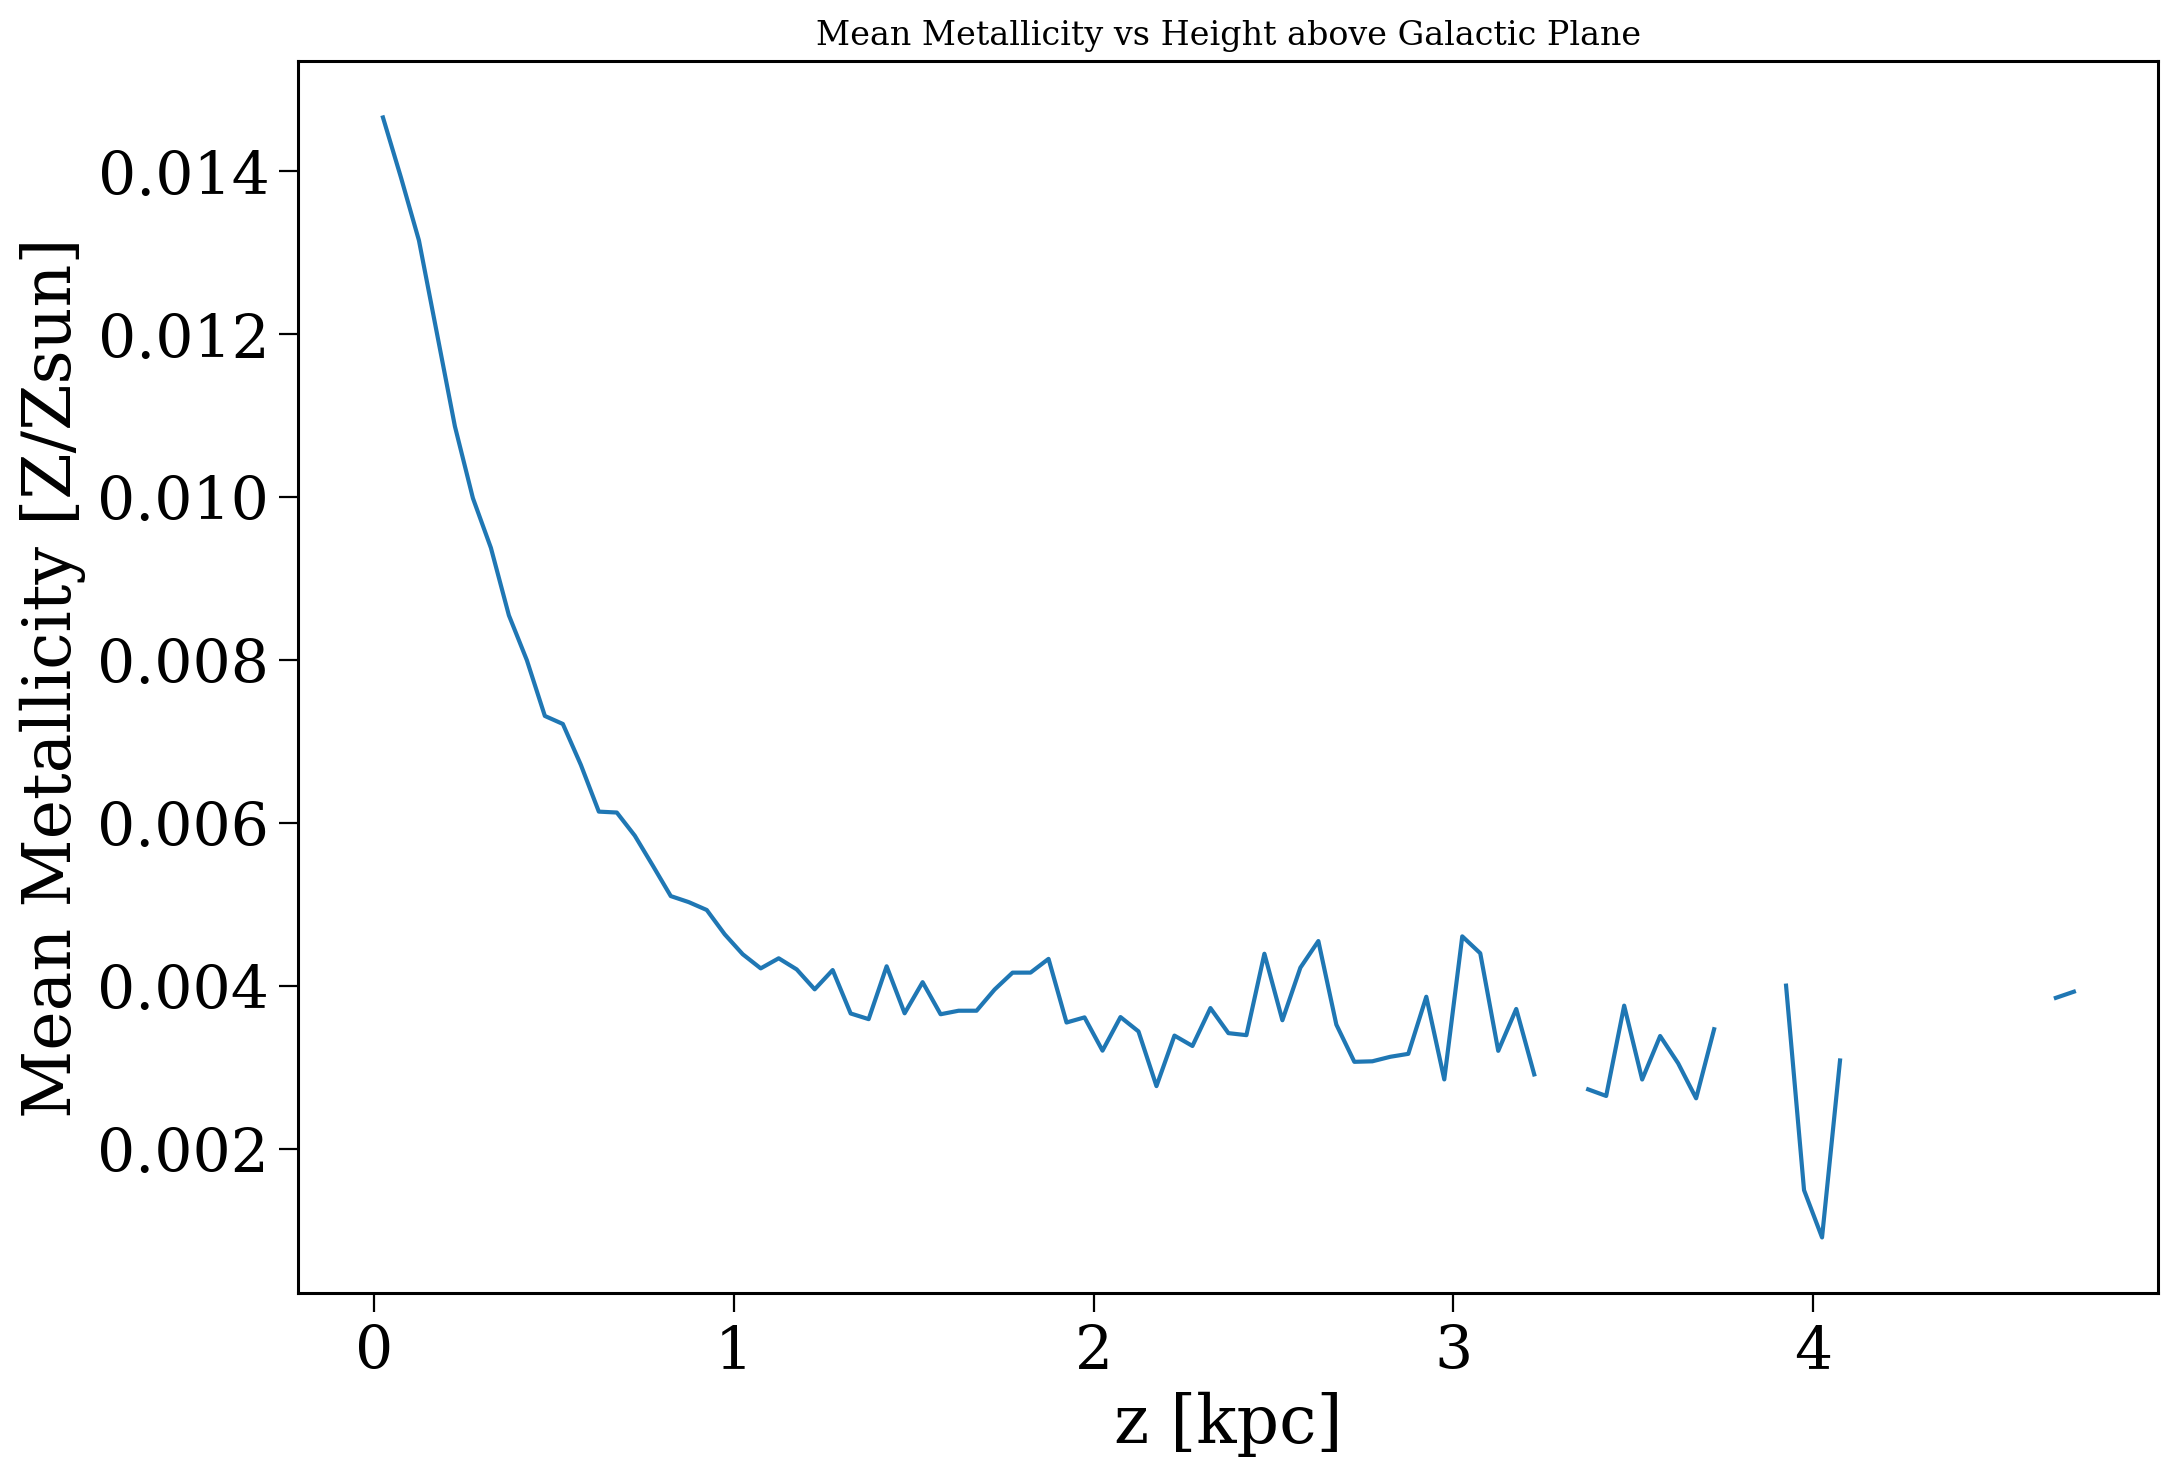

In [10]:
# plot the average metallicity as a function of z, moving window
window_size = 0.05 * u.kpc
z_bins = np.arange(0, 5, 0.05) * u.kpc
z_centers = z_bins[:-1] + np.diff(z_bins) / 2
mean_metallicity = []
for z_center in z_centers:
    in_window = (stars.z >= (z_center - window_size / 2)) & (stars.z < (z_center + window_size / 2))
    if np.sum(in_window) > 0:
        mean_metallicity.append(np.mean(stars.Z.value[in_window]))
    else:
        mean_metallicity.append(np.nan)

plt.plot(z_centers, mean_metallicity)
plt.xlabel("z [kpc]")
plt.ylabel("Mean Metallicity [Z/Zsun]")
plt.title("Mean Metallicity vs Height above Galactic Plane")
plt.show()

0.02853202588942541


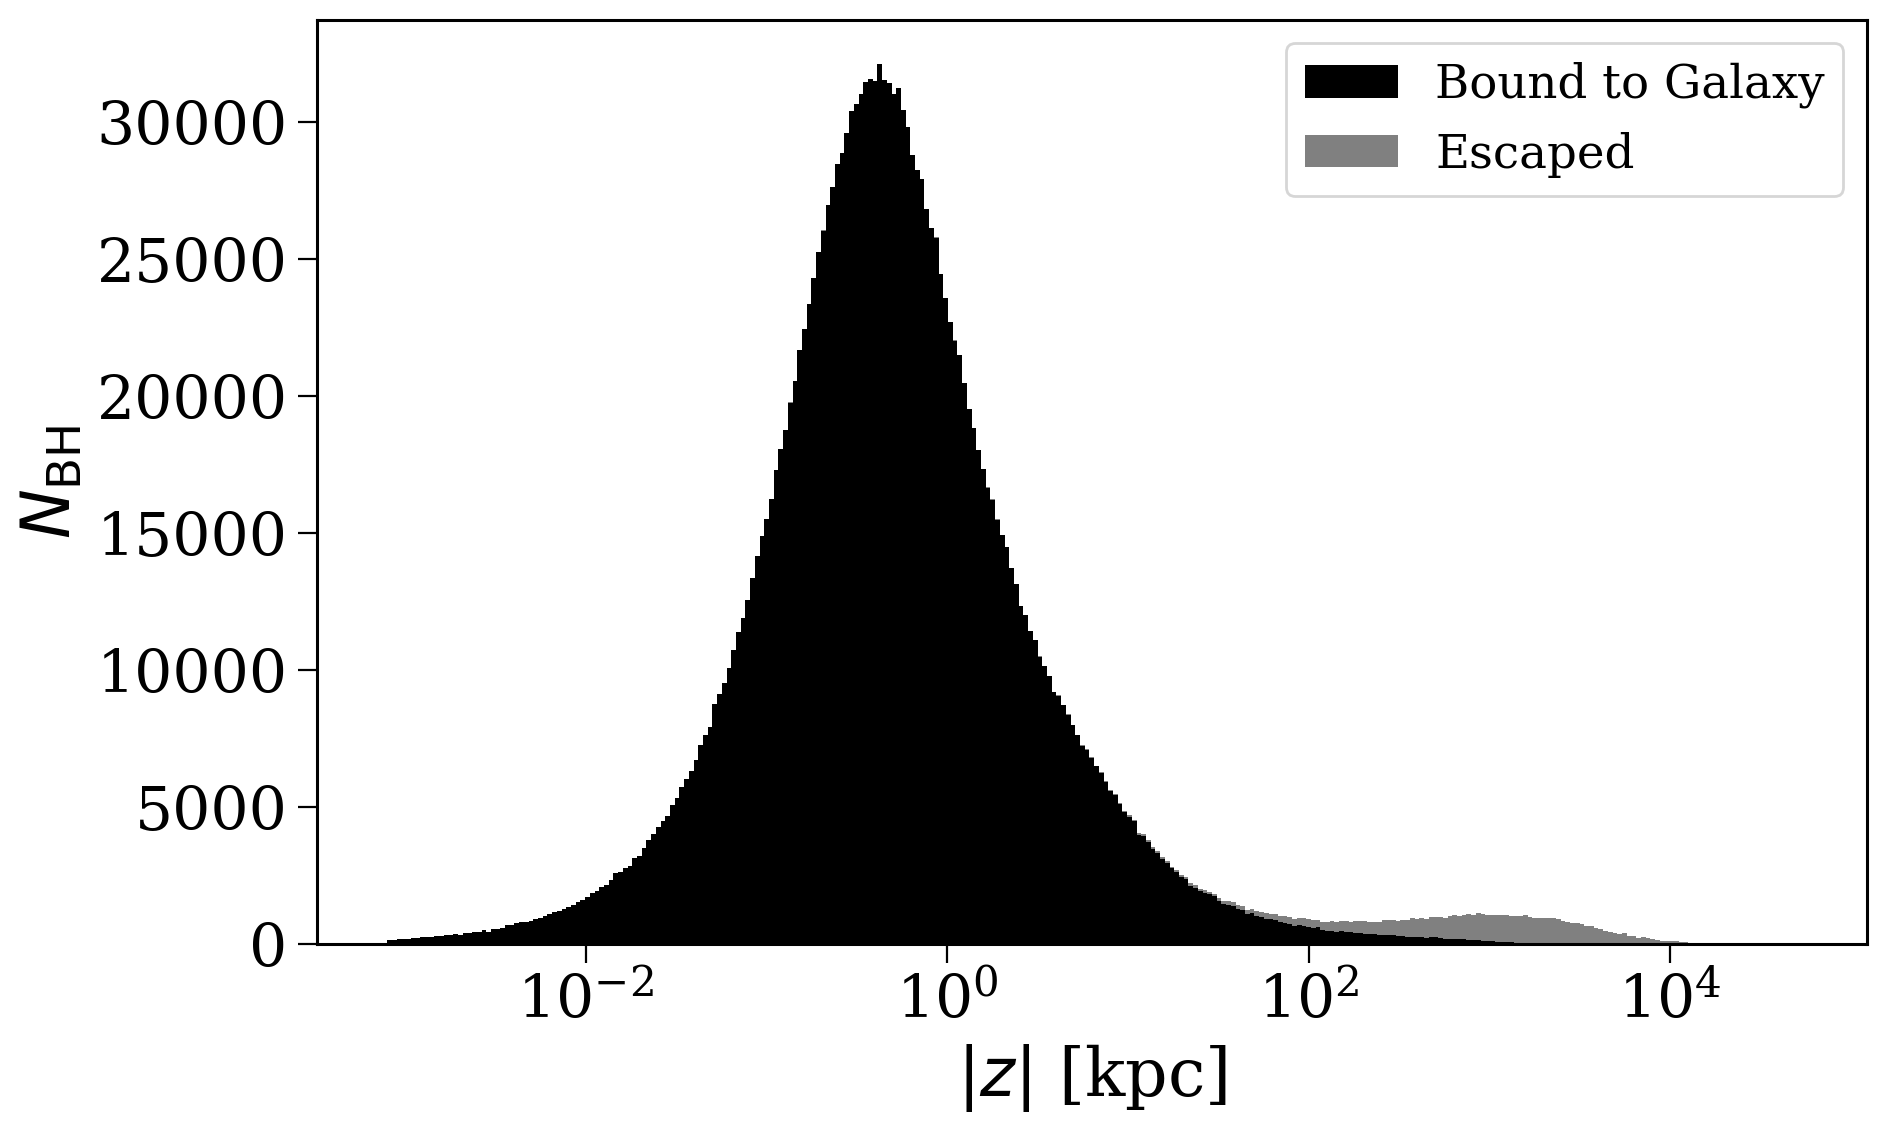

In [99]:
fig, ax = plt.subplots(figsize=(10, 6))

co_pos = kinematics[pop.label]["pos"]["BH"]
co_vel = kinematics[pop.label]["vel"]["BH"]

co_V = np.linalg.norm(co_vel.to(u.km/u.s).value, axis=1)

mask = co_V >= np.sqrt(-2 * pop.galactic_potential(co_pos.T)).to(u.km / u.s).value

abs_z = np.abs(co_pos[:, 2].to(u.kpc).value)

print(mask.sum() / len(mask))

ax.hist([abs_z[~mask], abs_z[mask]], bins=np.geomspace(8e-4, 5e4, 300), stacked=True,
        color=['black', 'grey'], label=['Bound to Galaxy', 'Escaped'])

# ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, histtype='step', lw=2, color=pop.colour)
# ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, alpha=0.4, color=pop.colour,
#         label=f'{pop.label} (N={len(co_pos[mask])})')

ax.set(
    xscale="log",
    xlabel=r'$|z|$ [kpc]',
    ylabel=r'$N_{\rm BH}$',
)
ax.legend(title=None)
plt.show()

In [46]:
bh_bin_nums = np.concatenate((
    pop.final_bpp["bin_num"][pop.final_bpp["kstar_1"] == 14],
    pop.final_bpp["bin_num"][pop.final_bpp["kstar_2"] == 14]
))

In [47]:
n_primary_bh = (pop.final_bpp["kstar_1"] == 14).sum()

In [48]:
primary_escaped_bh_kicks = pop.kick_info.loc[bh_bin_nums[:n_primary_bh][kinematics["Fiducial"]["escaped"]["BH"][:n_primary_bh]]]
primary_escaped_bh_kick_mags = primary_escaped_bh_kicks[primary_escaped_bh_kicks["star"] == 1.0]["natal_kick"]

secondary_escaped_bh_kicks = pop.kick_info.loc[bh_bin_nums[n_primary_bh:][kinematics["Fiducial"]["escaped"]["BH"][n_primary_bh:]]]
secondary_escaped_bh_kick_mags = secondary_escaped_bh_kicks[secondary_escaped_bh_kicks["star"] == 2.0]["natal_kick"]

escaped_bh_kick_mags = pd.concat((primary_escaped_bh_kick_mags, secondary_escaped_bh_kick_mags))

primary_bh_kicks = pop.kick_info.loc[bh_bin_nums[:n_primary_bh]]
primary_bh_kick_mags = primary_bh_kicks[primary_bh_kicks["star"] == 1.0]["natal_kick"]
secondary_bh_kicks = pop.kick_info.loc[bh_bin_nums[n_primary_bh:]]
secondary_bh_kick_mags = secondary_bh_kicks[secondary_bh_kicks["star"] == 2.0]["natal_kick"]
bh_kick_mags = pd.concat((primary_bh_kick_mags, secondary_bh_kick_mags))

print(np.percentile(bh_kick_mags, [2.5, 16, 50, 84, 97.5]))
print(np.percentile(escaped_bh_kick_mags, [2.5, 16, 50, 84, 97.5]))

[  0.           0.          85.47631679 239.97617235 537.00343371]
[ 331.61660796  425.33118053  588.95946957  861.26805533 1355.37304767]


In [204]:
(abs_z < 10).sum() / len(abs_z)

np.float64(0.9263841706958724)

[ 2.24343308  7.81450392 15.06637873 16.97731672]
[ 6.33387755 25.53338298]


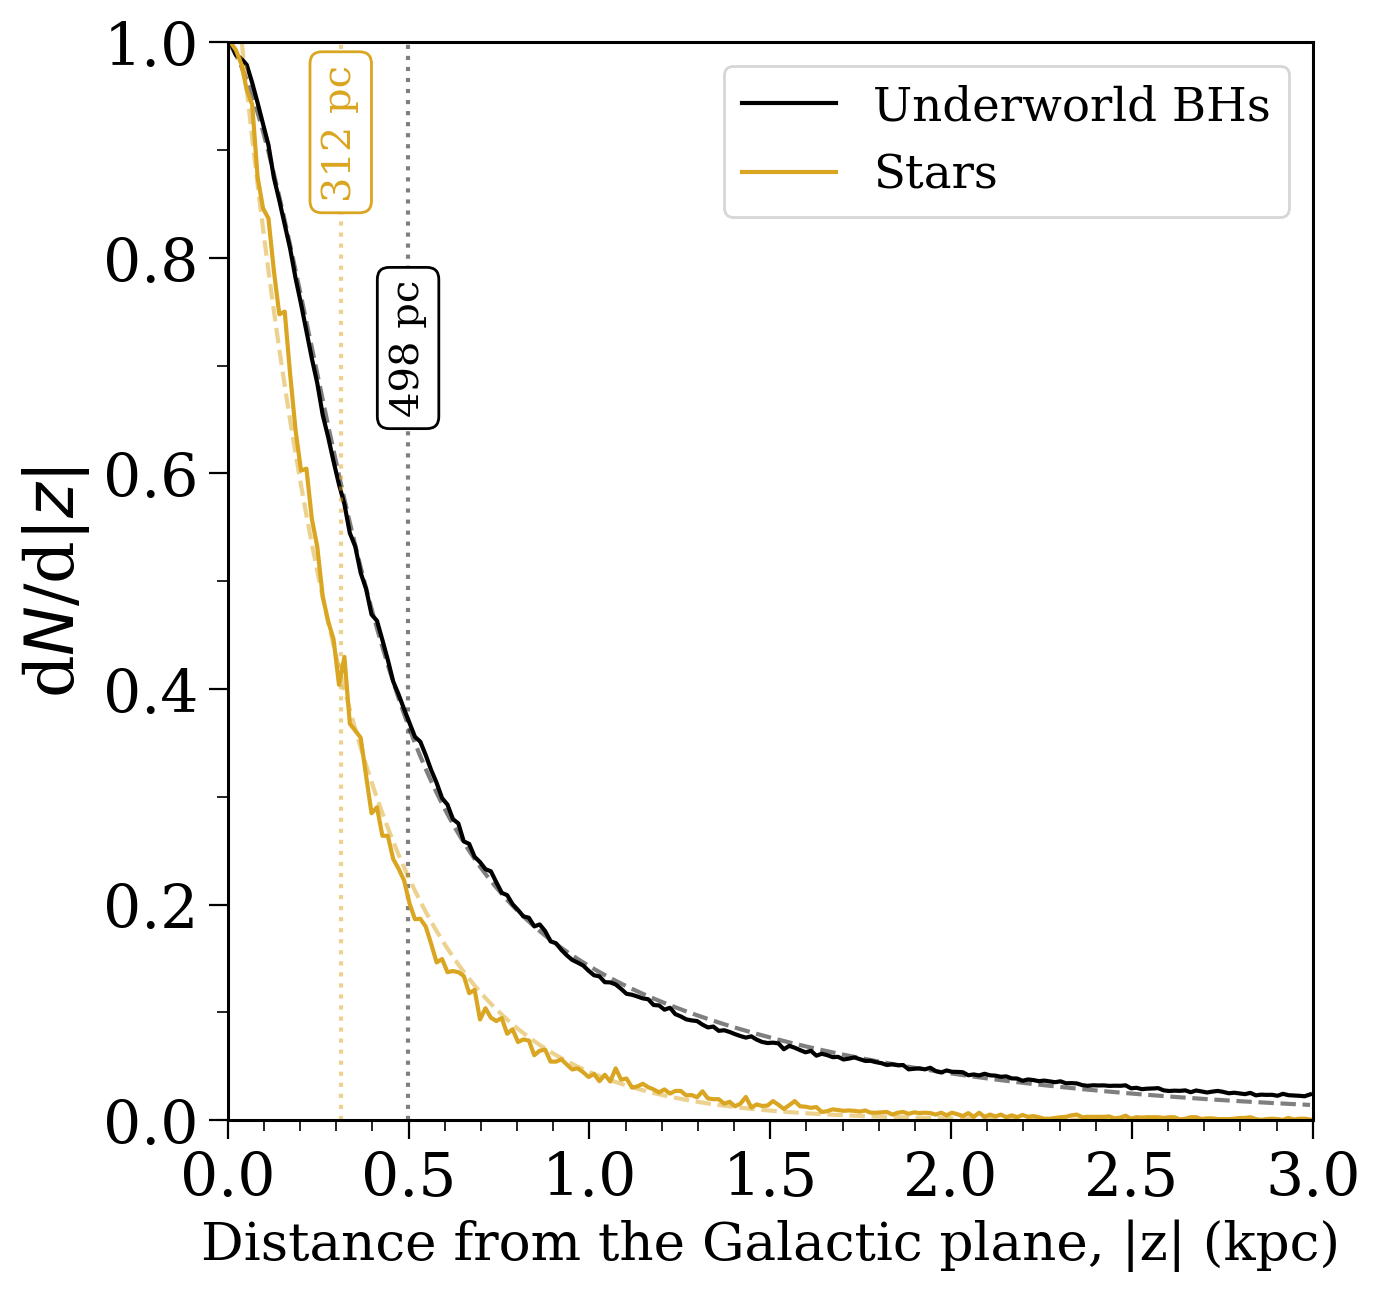

In [201]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, R, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["BH"][:, 2], stars.z],
    [np.linalg.norm(kinematics["Fiducial"]["pos"]["BH"][:, :2], axis=1), stars.rho],
    ["Underworld BHs", "Stars"],
    ["black", "goldenrod"]
):

    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2 if label.startswith("Underworld") else 1,
        scale_height_locs=[0.78 if label.startswith("Underworld") else 0.98, 0.22],
        R=None,
    )

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_blackholes_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

{'norm': <matplotlib.colors.LogNorm object at 0x1470e53279d0>}
{'norm': <matplotlib.colors.LogNorm object at 0x1470e51ad710>}


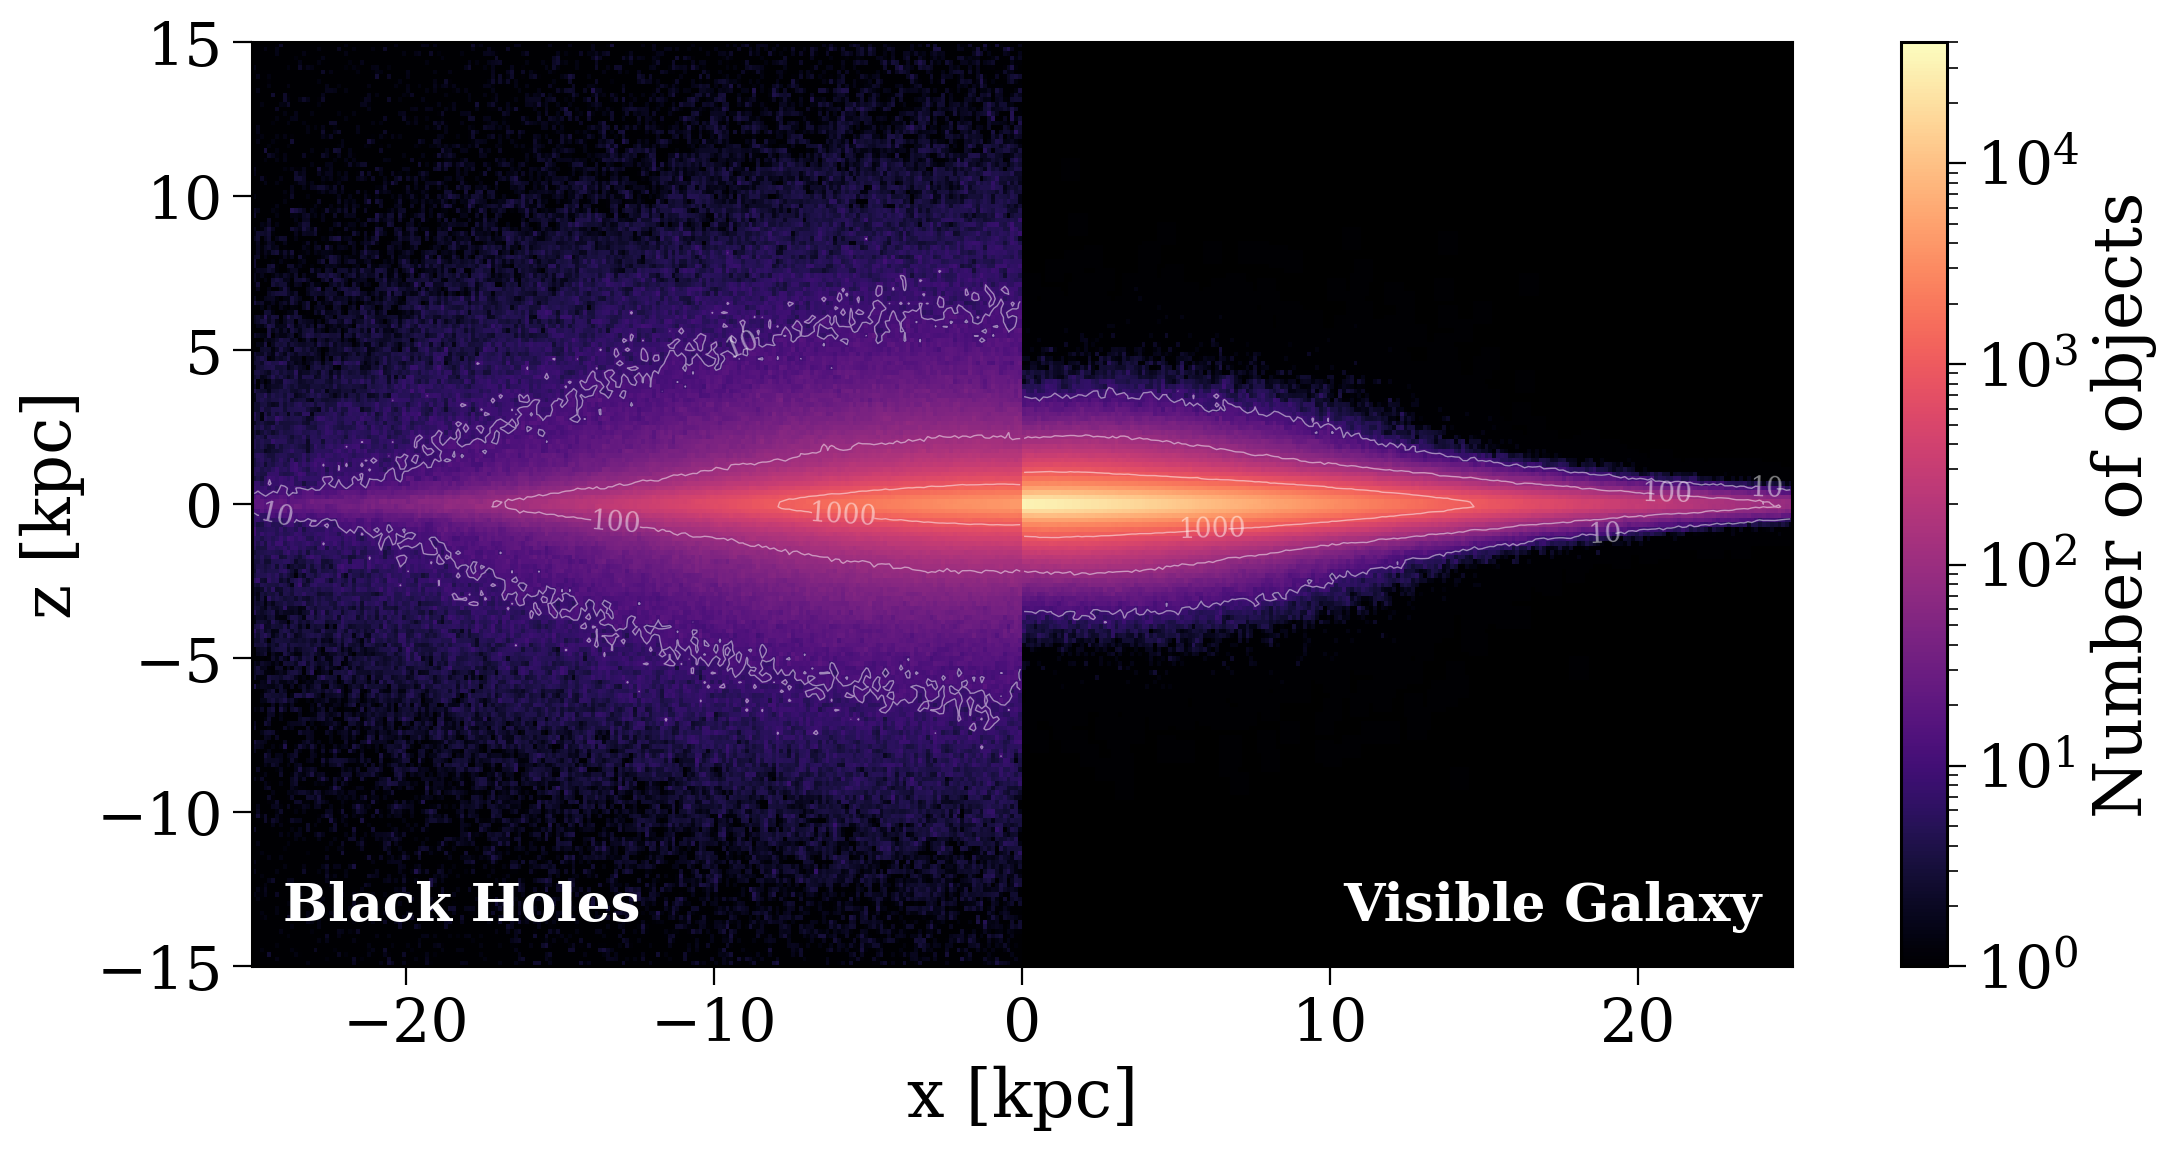

In [37]:
reload(plotting)
fig, ax = plotting.plot_side_on_density(
    xs=[stars.x, kinematics["Fiducial"]["pos"]["BH"][:, 0]],
    zs=[stars.z, kinematics["Fiducial"]["pos"]["BH"][:, 2]],
    labels=["Black Holes", "Visible Galaxy"],
    xlim=25,
    zlim=15,
    n_bins=200,
    sigma=0.5,
    contours=[10, 100, 1000],
    apply_smoothing=True,
    show=False,
    norm="log",
)

plt.savefig("../plots/density_stars_vs_blackholes.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Mass distribution

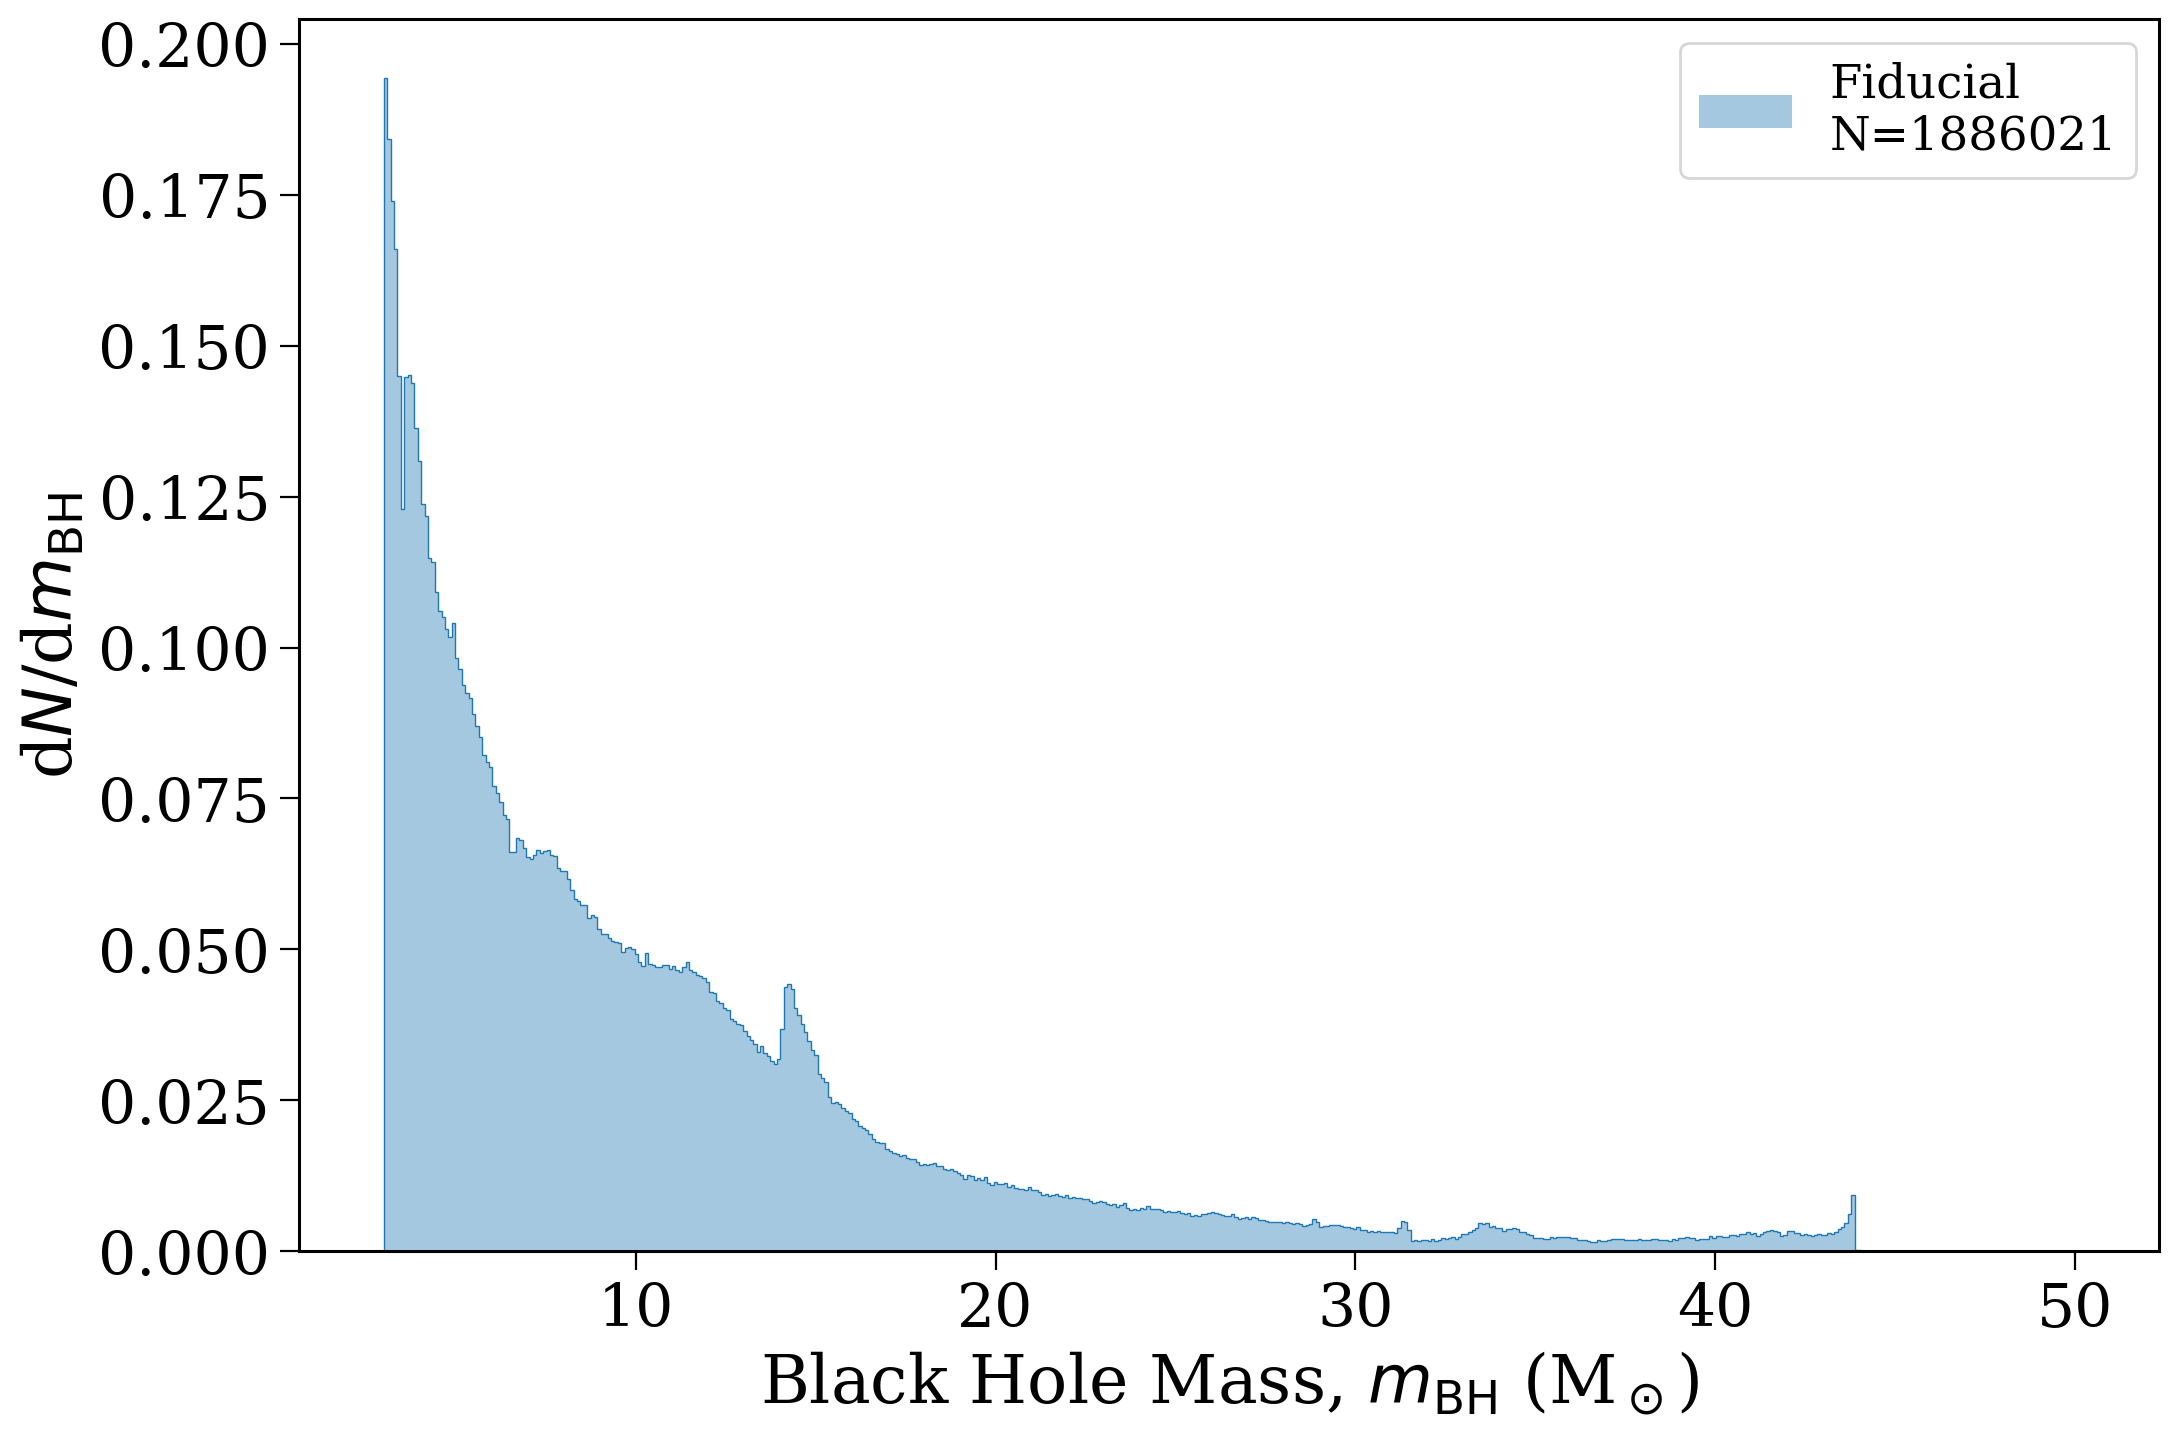

In [49]:
reload(plotting)
fig, ax = plotting.compare_table_quantity(
    pops=[pop],
    quantity="mass",
    kstar=14,
    bins=np.linspace(3, 50, 500),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False,
    lw=0.5
)
plt.savefig("../plots/bh_mass_distribution.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Spatial vs. Mass

Larger mass objects (particularly BHs) are going to get different kicks, we should see that show up in their distribution

In [50]:
masses = {
    "BH": np.concatenate((
        pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
        pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
    )),
    "NS": np.concatenate((
        pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
        pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
    )),
}
masses["CO"] = np.concatenate((masses["NS"], masses["BH"]))

In [51]:
z_range = np.geomspace(0.1, 10, 1000)
window_width = .1

init_bh_z = np.concatenate((pop.initial_galaxy.z[pop.final_bpp["kstar_1"] == 14],
                            pop.initial_galaxy.z[pop.final_bpp["kstar_2"] == 14]))
init_abs_z = np.abs(init_bh_z.to(u.kpc).value)
init_mean_bh = np.zeros(len(z_range))
abs_z = np.abs(kinematics[pop.label]["pos"]["BH"][:, 2]).to(u.kpc).value
mean_bh = np.zeros(len(z_range))
for i, z in enumerate(z_range):
    in_window = (abs_z >= z - window_width / 2) & (abs_z < z + window_width / 2)
    mean_bh[i] = np.mean(masses["BH"][in_window])

    in_window_init = (init_abs_z >= z - window_width / 2) & (init_abs_z < z + window_width / 2)
    init_mean_bh[i] = np.mean(masses["BH"][in_window_init])

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



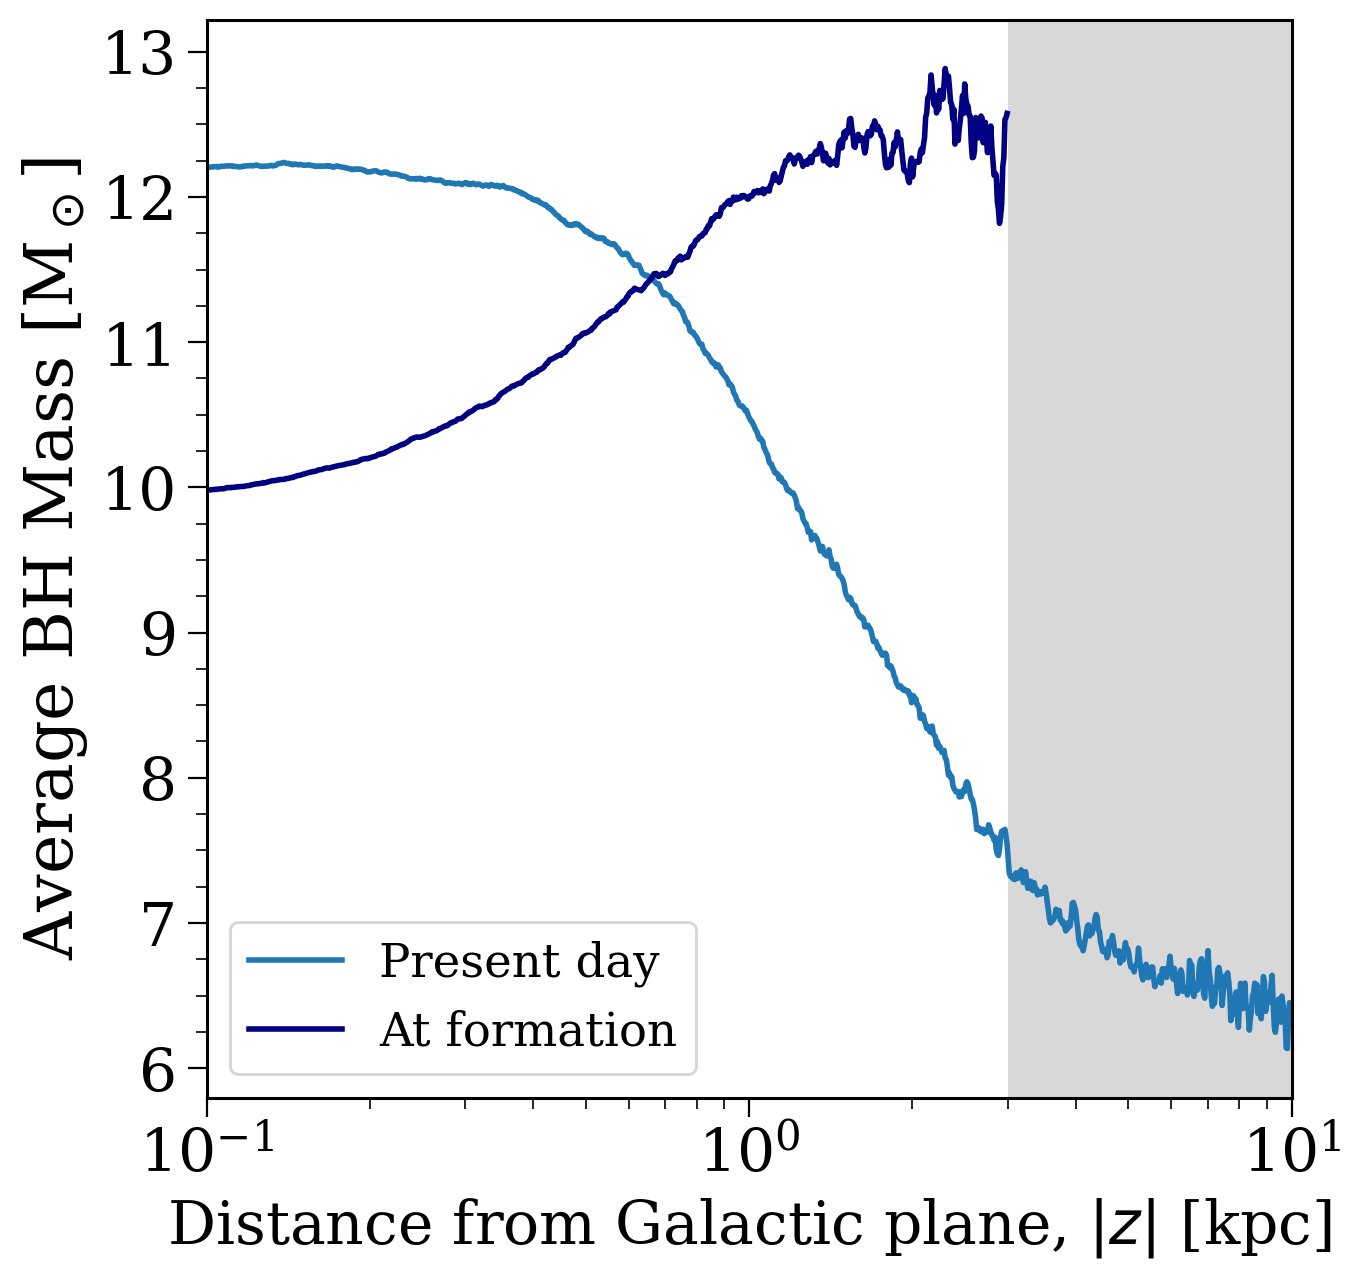

In [52]:
# plot the average mass as a function of |z|
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(z_range,mean_bh, lw=2, label="Present day")
ax.plot(z_range[z_range < 3],init_mean_bh[z_range < 3], lw=2, label="At formation", color="navy")

ax.axvspan(3, 10, color='gray', alpha=0.3, lw=0)

ax.set(
    xscale="log",
    xlabel=r'Distance from Galactic plane, $|z|$ [kpc]',
    ylabel='Average BH Mass [M$_\odot$]',
    xlim=(z_range.min(), z_range.max())
)

ax.set_xlabel(ax.get_xlabel(), fontsize=0.9*fs)

ax.legend()

ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.25))

plt.savefig("../plots/average_bh_mass_vs_z.pdf", format="pdf", bbox_inches='tight')
plt.show()

## Stats

In [19]:
average_escaped_BH_mass = np.mean(masses["BH"][kinematics[pop.label]["escaped"]["BH"]])
average_bound_BH_mass = np.mean(masses["BH"][~kinematics[pop.label]["escaped"]["BH"]])

In [20]:
avg_bound_BH_close_to_disc = np.mean(masses["BH"][(
    ~kinematics[pop.label]["escaped"]["BH"] &
    (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) < 1)
)])

avg_bound_BH_far_from_disc = np.mean(masses["BH"][(
    ~kinematics[pop.label]["escaped"]["BH"] &
    (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) >= 1)
)])

In [21]:
print("Average BH masses:")
print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")

Average BH masses:
  Escaped: 5.2 Msun
  Bound:   10.7 Msun
    Close to disc (<1 kpc):  11.9 Msun
    Far from disc (>=1 kpc): 8.0 Msun


In [22]:
# convert the above print statements to a LaTeX table
print("\nLaTeX table:")
print(r"\begin{tabular}{l c}")
print(r"  \hline")
print(r"  Population & Average BH Mass (M$_\odot$) \\")
print(r"  \hline")
print(f"  Escaped & {average_escaped_BH_mass:.1f} \\")
print(f"  Bound & {average_bound_BH_mass:.1f} \\")
print(f"  \quad Close to disc (<1 kpc) & {avg_bound_BH_close_to_disc:.1f} \\")
print(f"  \quad Far from disc (>=1 kpc) & {avg_bound_BH_far_from_disc:.1f} \\")
print(r"  \hline")
print(r"\end{tabular}")


LaTeX table:
\begin{tabular}{l c}
  \hline
  Population & Average BH Mass (M$_\odot$) \\
  \hline
  Escaped & 5.2 \
  Bound & 10.7 \
  \quad Close to disc (<1 kpc) & 11.9 \
  \quad Far from disc (>=1 kpc) & 8.0 \
  \hline
\end{tabular}


# Progenitors

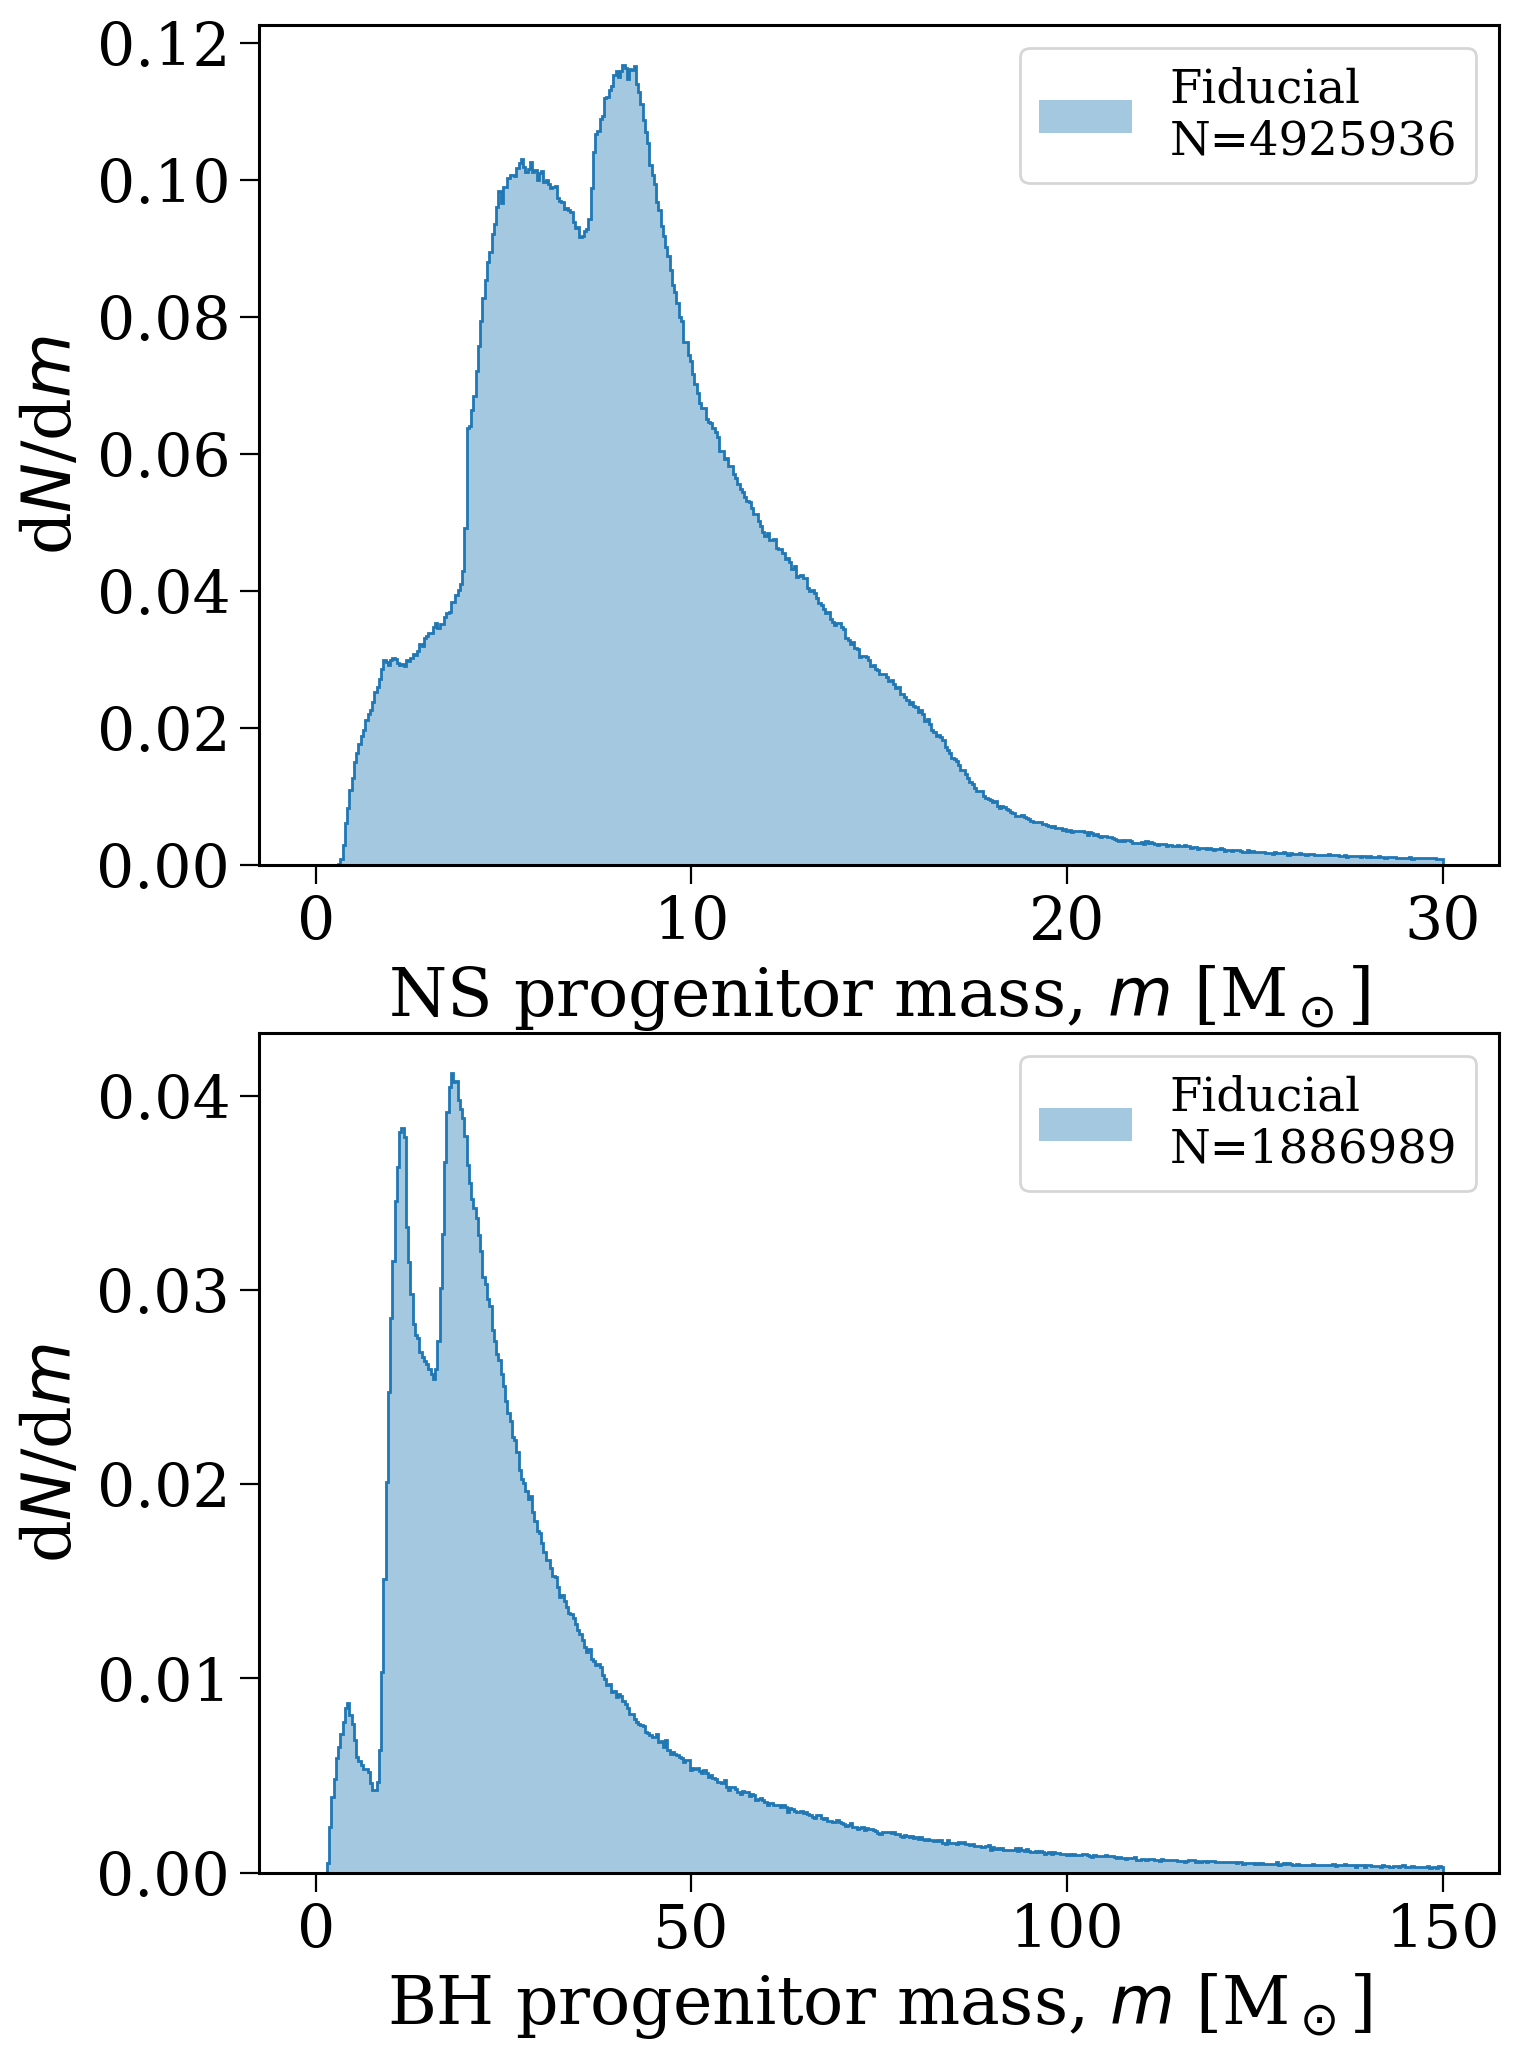

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 501), np.linspace(0, 150, 501)]):
    plotting.compare_table_quantity(
        pops=[pop],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} progenitor mass, $m$ [M$_\odot$]",
        ylabel=f"d$N$/d$m$",
        density=True,
        ax=ax,
        fig=fig,
        show=False,
        lw=1
    )

plt.savefig("../plots/progenitor_masses.pdf", format="pdf", bbox_inches='tight')
plt.show()

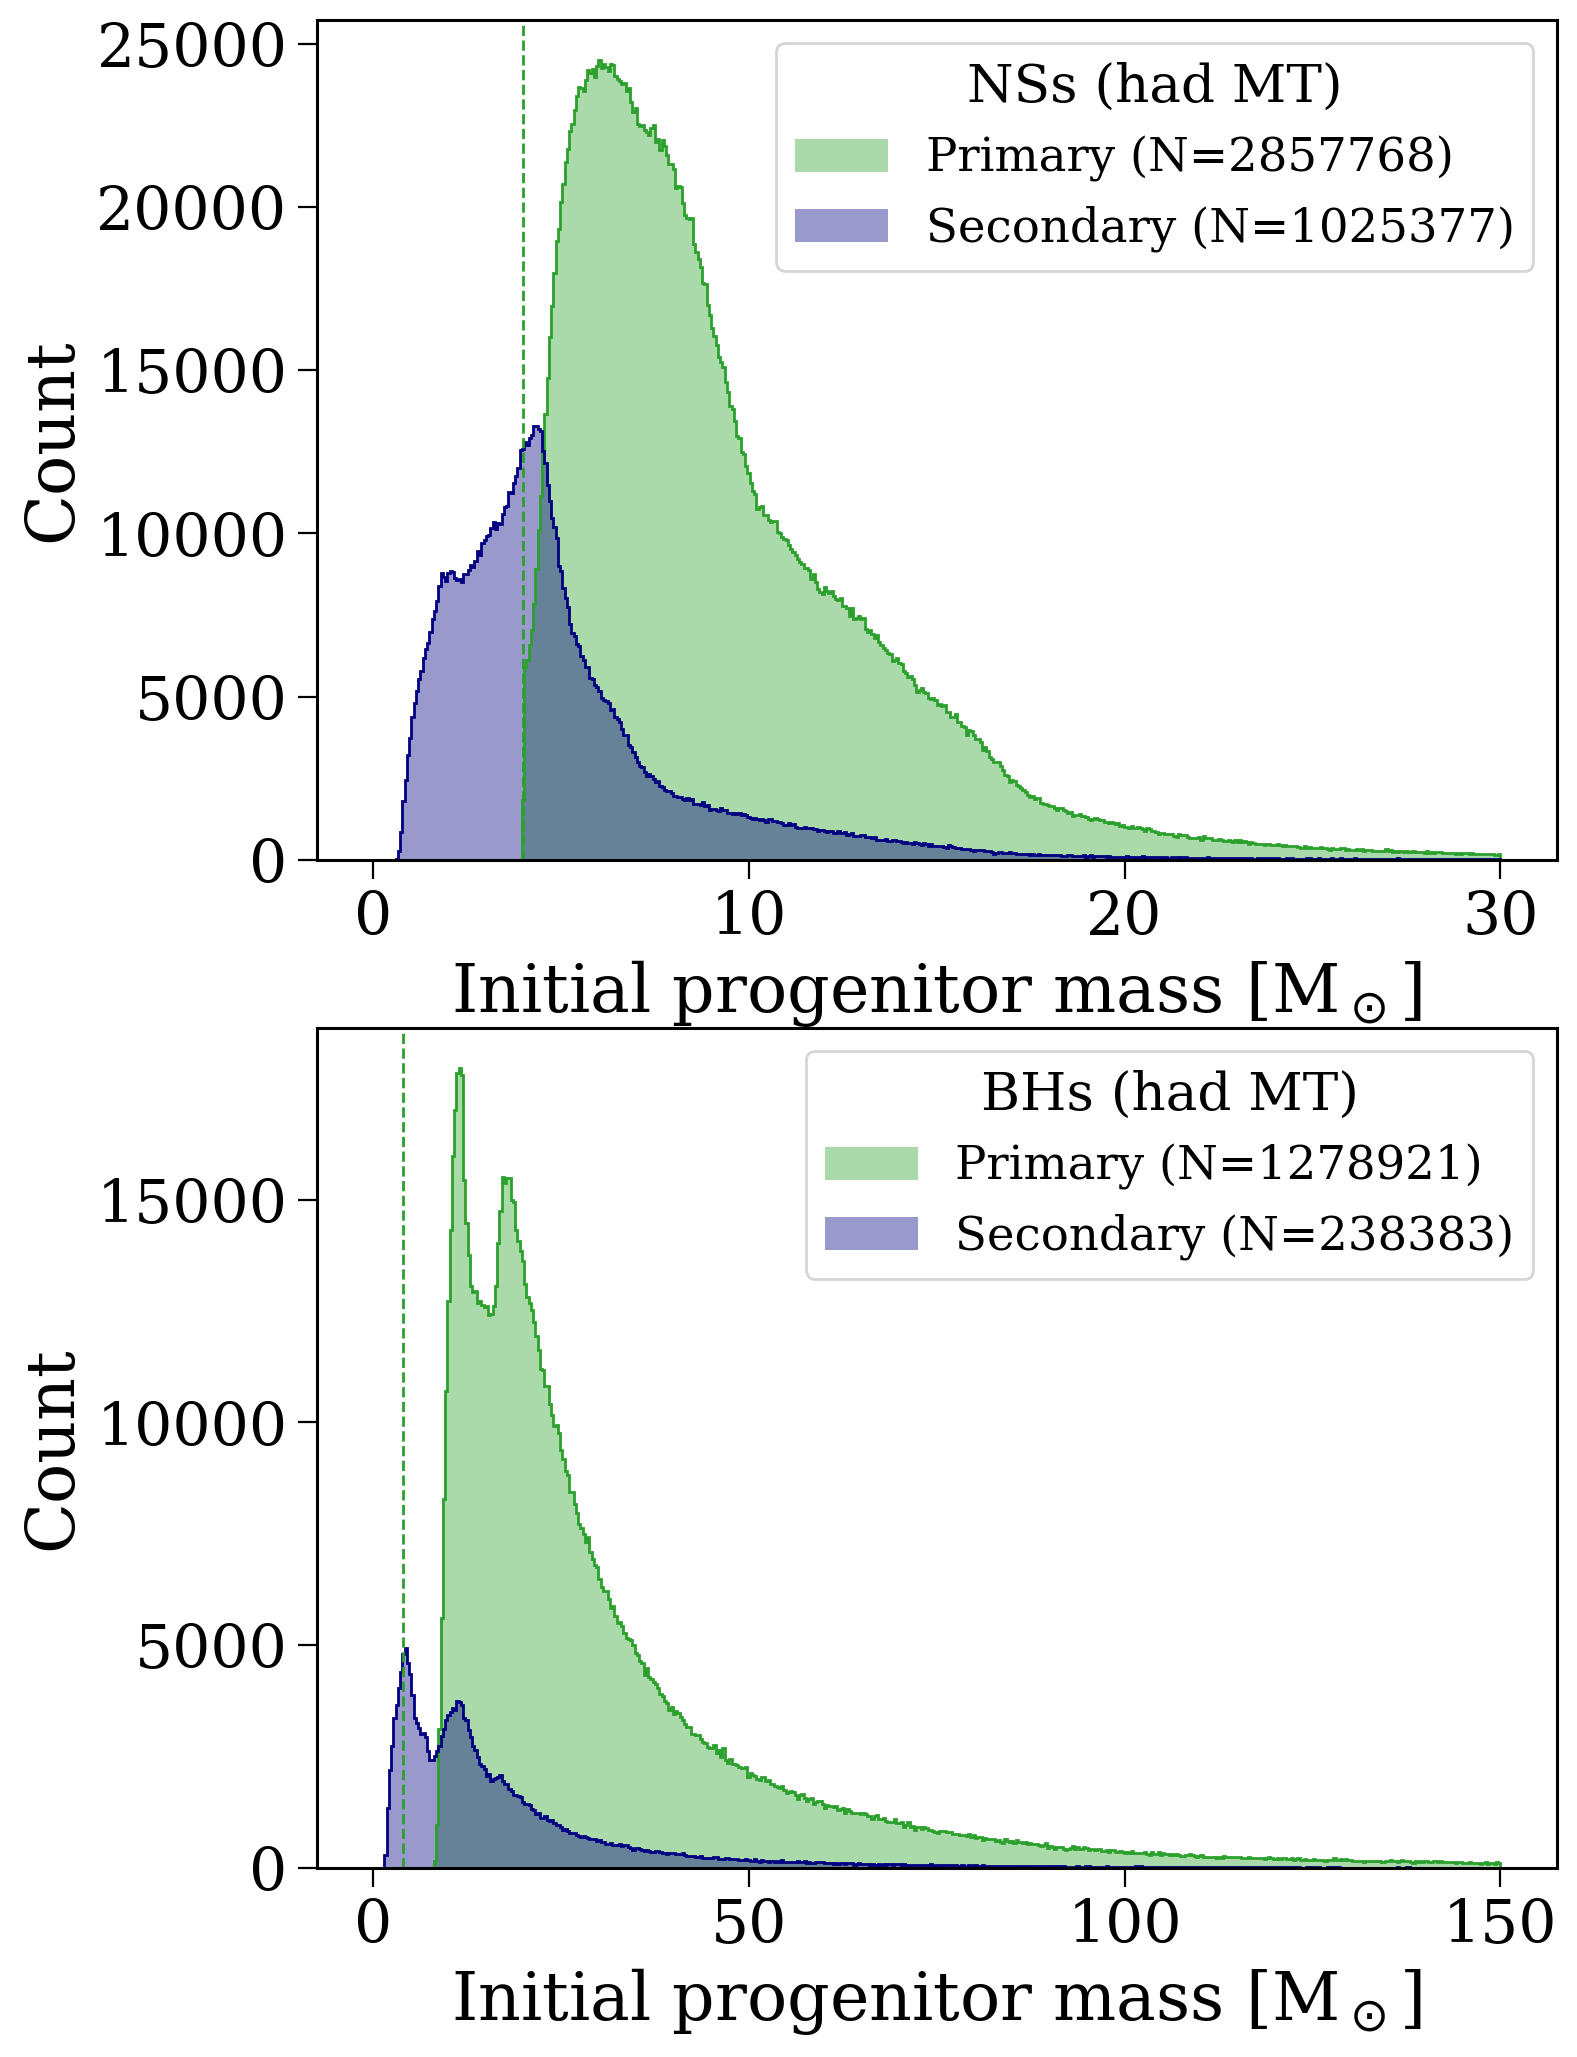

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 501), np.linspace(0, 150, 501)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            # & ~(pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=1, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")
        
    ax.axvline(4, color="tab:green", ls='--', lw=1)

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had MT)")

plt.savefig("../plots/progenitor_masses_mt.pdf", format="pdf", bbox_inches='tight')
plt.show()

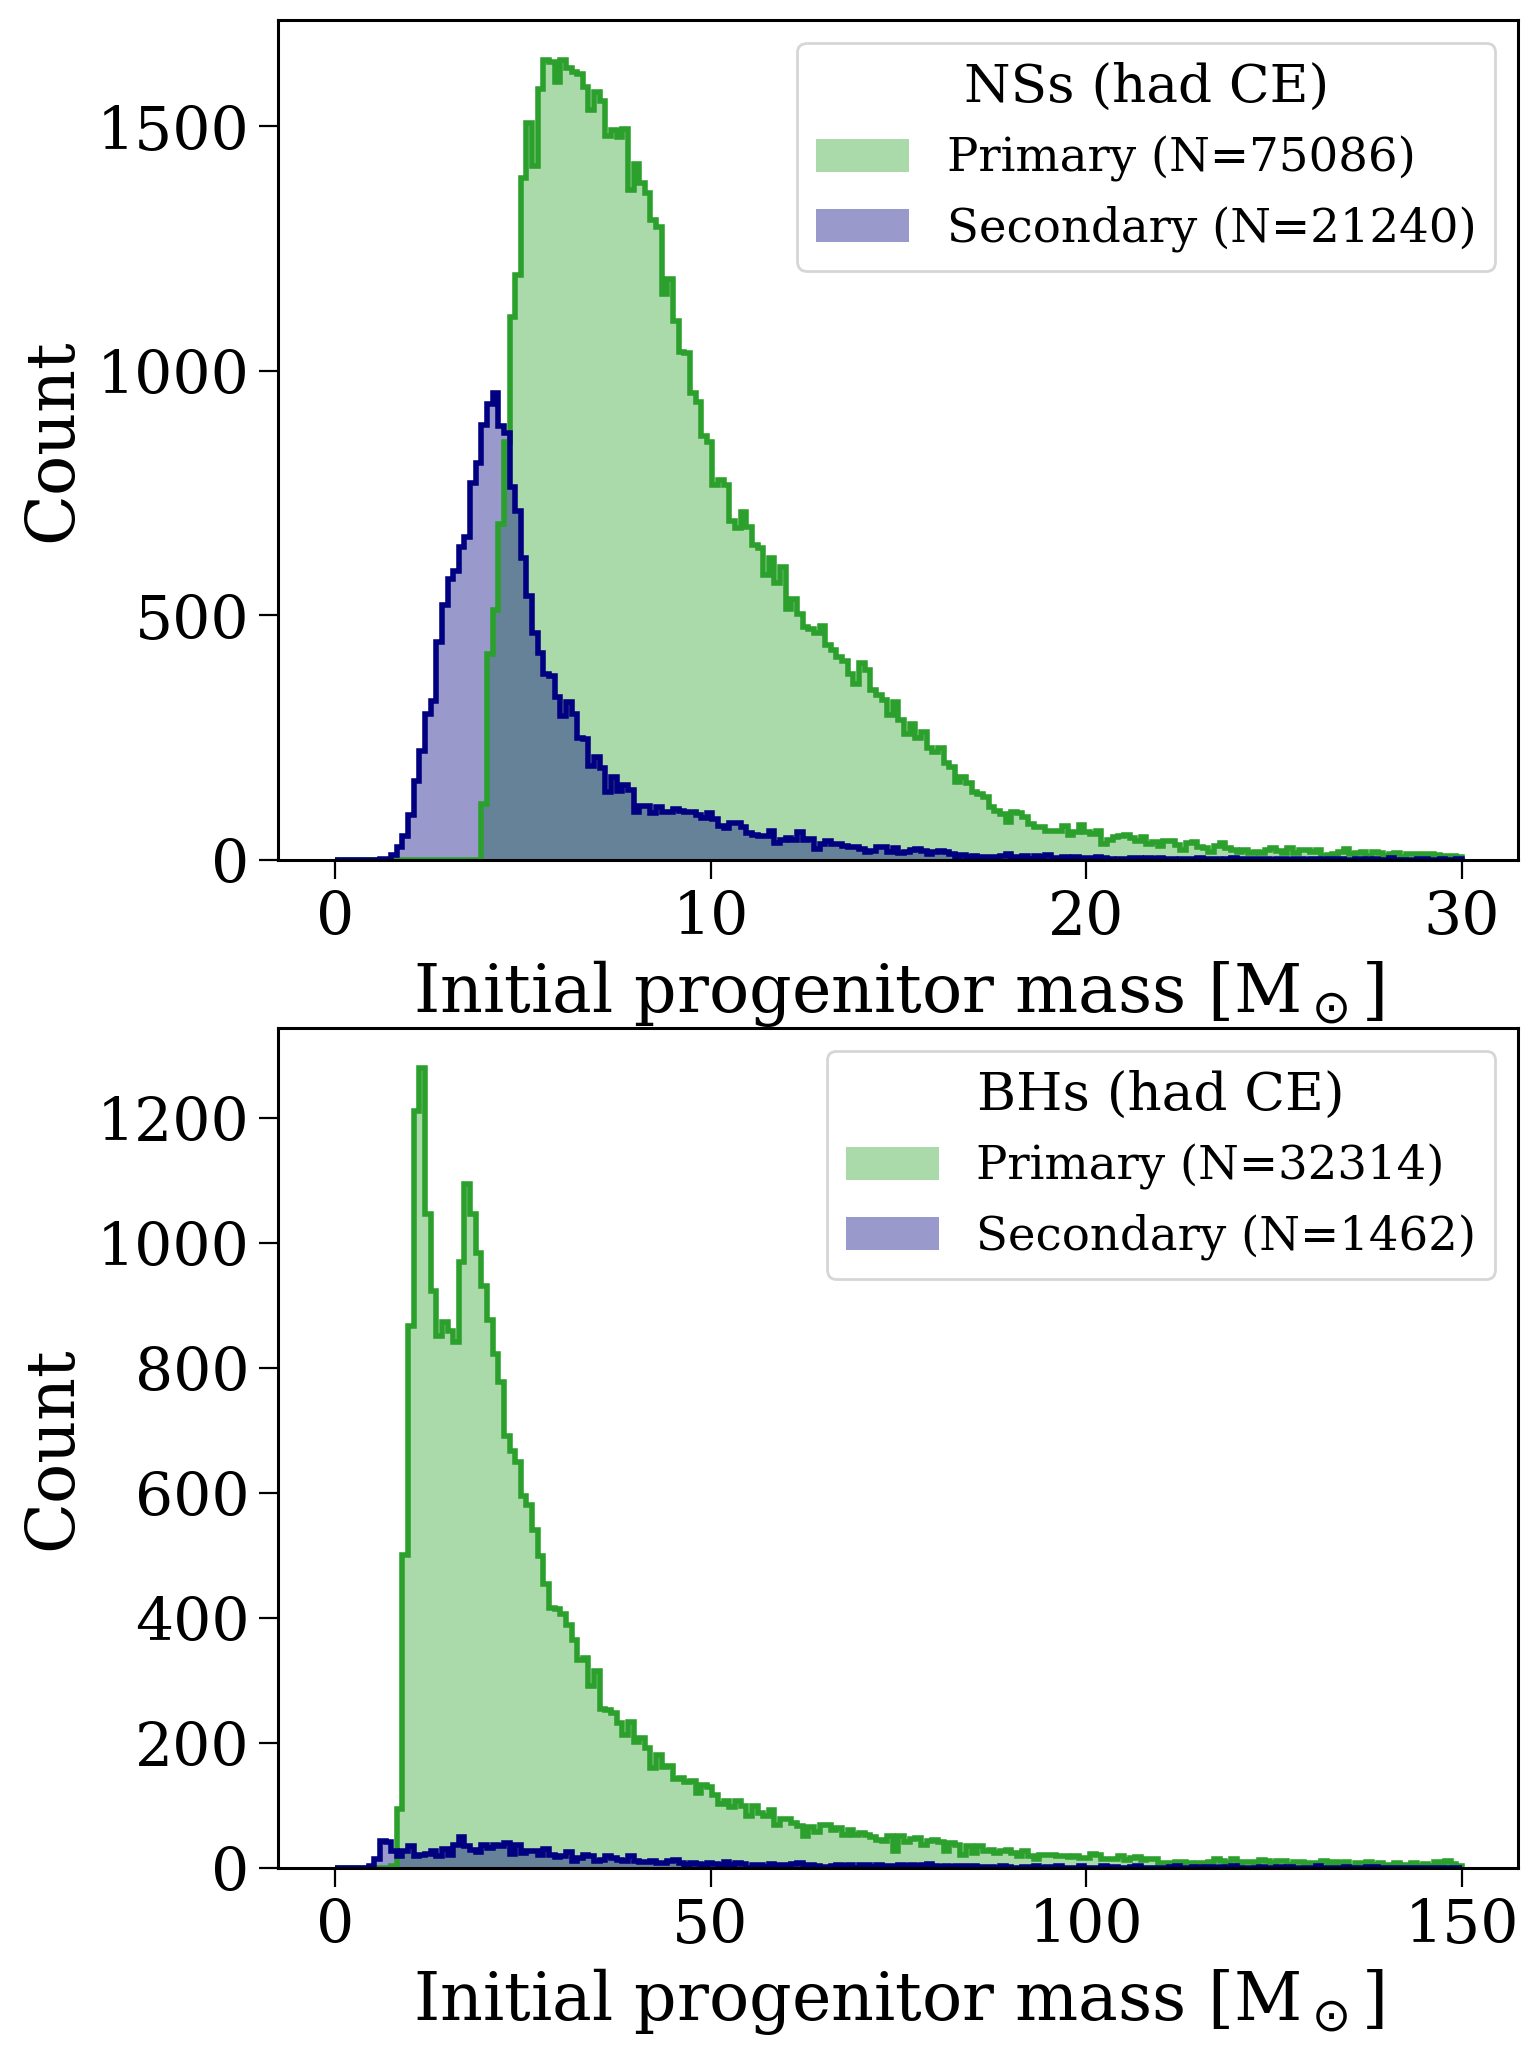

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            & (pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=2, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had CE)")

plt.savefig("../plots/progenitor_masses_ce.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Compare to Sweeney scale heights

In [54]:
sweeney = pd.read_csv("~/ceph/underworld/sweeney_data/kicked_remnants_igoshev_young_7.8_DC_integrated_final.csv")

[ 2.24343308  7.81450392 15.06637873 16.97731672]
73571 objects before Rlims
2283 objects in Rlims
[18.16329172 27.84662695]
[ 5.03037564 22.5967358  31.99278427 24.565371  ]


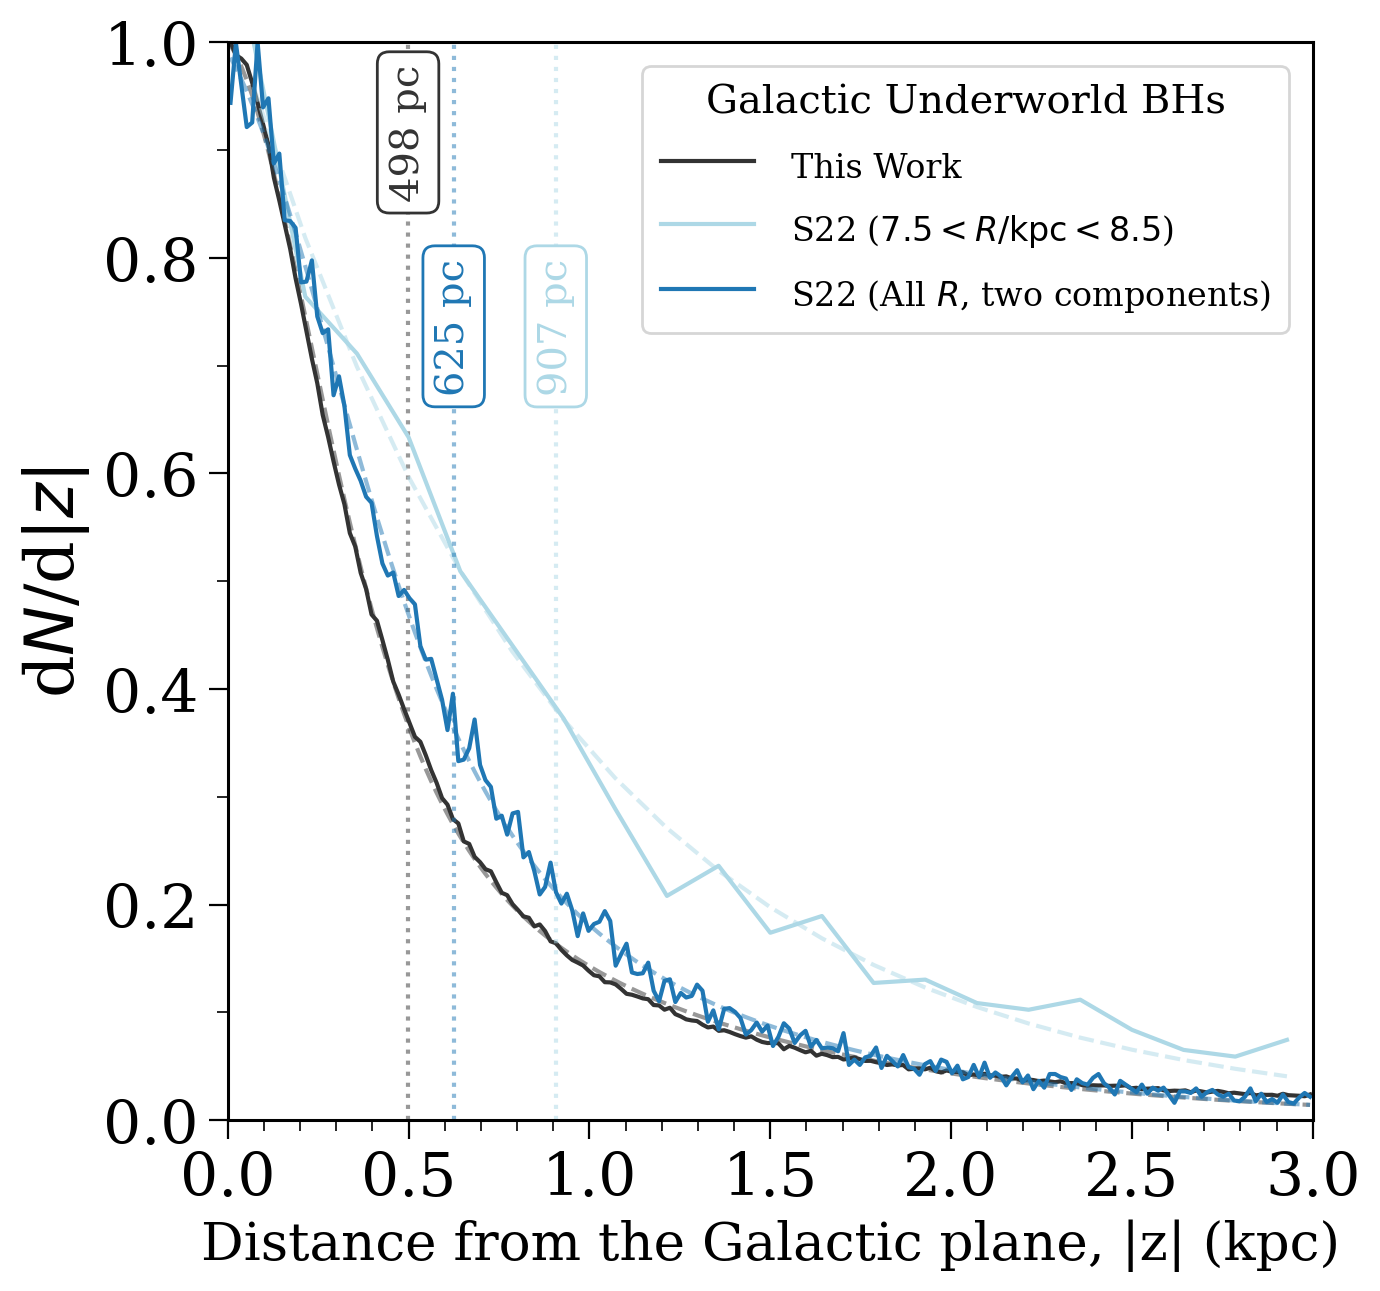

In [58]:
reload(plotting)

sweeney_bhs = sweeney[(sweeney["rtype"] == "Black Hole") & ~sweeney["will_escape"]]

fig, ax = plt.subplots(figsize=(7, 7))

plotting.estimate_scale_height(
    z=kinematics["Fiducial"]["pos"]["BH"][:, 2],
    plot=True,
    label=r"This Work",
    colour="#333",
    fig=fig,
    ax=ax,
    show=False,
    bins=np.linspace(0, 3, 201),
    xlim=(0, 3),
    ylim=(0, 1),
    scale_height_locs=[0.98],
    n_components=2,
)

# plotting.estimate_scale_height(
#     z=kinematics["Fiducial"]["pos"]["BH"][:, 2],
#     R=np.linalg.norm(kinematics["Fiducial"]["pos"]["BH"][:, :2], axis=1),
#     plot=True,
#     label=r"This Work",
#     colour="#999",
#     fig=fig,
#     ax=ax,
#     show=False,
#     bins=np.linspace(0, 3, 201),
#     xlim=(0, 3),
#     ylim=(0, 1),
#     scale_height_locs=[0.2],
#     n_components=2,
# )

plotting.estimate_scale_height(
    z=sweeney_bhs["pz"].values * u.kpc,
    R= sweeney_bhs["R"].values * u.kpc,
    plot=True,
    label=r"S22 ($7.5 < R / {\rm kpc} < 8.5$)",
    colour="lightblue",
    fig=fig,
    ax=ax,
    show=False,
    bins="auto",
    xlim=(0, 3),
    ylim=(0, 1),
    n_components=1,
    scale_height_locs=[0.8],
)

plotting.estimate_scale_height(
    z=sweeney_bhs["pz"].values * u.kpc,
    plot=True,
    label=r"S22 (All $R$, two components)",
    colour="tab:blue",
    fig=fig,
    ax=ax,
    show=False,
    bins=np.linspace(0, 3, 201),
    xlim=(0, 3),
    ylim=(0, 1),
    n_components=2,
    scale_height_locs=[0.8],
)

leg = ax.get_legend()
leg.set_title("Galactic Underworld BHs", prop={'size': 0.6 * fs})
for text in leg.get_texts():
    text.set_fontsize(0.5 * fs)

ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

plt.savefig("../plots/scale_height_sweeney.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [60]:
pop.initC

,kstar_1,kstar_2,mass_1,mass_2,porb,ecc,metallicity,binfrac,tphysf,mass0_1,mass0_2,rad_1,rad_2,lum_1,lum_2,massc_1,massc_2,radc_1,radc_2,menv_1,menv_2,renv_1,renv_2,omega_spin_1,omega_spin_2,B_1,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,tms_1,tms_2,bhspin_1,bhspin_2,tphys,neta,bwind,hewind,alpha1,lambdaf,ceflag,tflag,ifflag,wdflag,pisn,rtmsflag,bhflag,remnantflag,grflag,bhms_coll_flag,wd_mass_lim,cekickflag,cemergeflag,cehestarflag,mxns,pts1,pts2,pts3,ecsn,ecsn_mlow,aic,ussn,sigma,sigmadiv,bhsigmafrac,polar_kick_angle,beta,xi,acc2,epsnov,eddfac,gamma,don_lim,acc_lim,bdecayfac,bconst,ck,windflag,qcflag,eddlimflag,dtp,randomseed,bhspinflag,bhspinmag,rejuv_fac,rejuvflag,htpmb,ST_cr,ST_tide,rembar_massloss,zsun,kickflag,bin_num,natal_kick_1,phi_1,theta_1,mean_anomaly_1,randomseed_1,natal_kick_2,phi_2,theta_2,mean_anomaly_2,randomseed_2,qcrit_0,qcrit_1,qcrit_2,qcrit_3,qcrit_4,qcrit_5,qcrit_6,qcrit_7,qcrit_8,qcrit_9,qcrit_10,qcrit_11,qcrit_12,qcrit_13,qcrit_14,qcrit_15,fprimc_0,fprimc_1,fprimc_2,fprimc_3,fprimc_4,fprimc_5,fprimc_6,fprimc_7,fprimc_8,fprimc_9,fprimc_10,fprimc_11,fprimc_12,fprimc_13,fprimc_14,fprimc_15,phase_sn_1,phase_sn_2,inc_sn_1,inc_sn_2
1,1.0,1.0,49.098082,9.232688,3.619484,0.027299,0.007573,1.0,6448.331316,49.098082,9.232688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,1.0,0.0,1,1,1,1,-2,0,1,4,1,0,1,2,1,0,3.0,0.001,0.01,0.02,2.25,1.6,1,1,265.0,-20.0,1.0,90.0,0.125,0.5,1.5,0.001,1,-2,-1,-1,1,3000,1000,3,5,0,6448.331316,1846097989,0,0.0,1.0,0,1,1,1,0.5,0.014,5,1,-100.000000,-100.000000,-100.000000,-100.0,0.000000e+00,22.157125,22.163761,185.816574,-100.0,-1.846098e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.347497,2.515544,0.962624,2.244743
3,1.0,1.0,15.263732,14.750221,30.588017,0.016552,0.018530,1.0,4840.381804,15.263732,14.750221,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,1.0,0.0,1,1,1,1,-2,0,1,4,1,0,1,2,1,0,3.0,0.001,0.01,0.02,2.25,1.6,1,1,265.0,-20.0,1.0,90.0,0.125,0.5,1.5,0.001,1,-2,-1,-1,1,3000,1000,3,5,0,4840.381804,-780487363,0,0.0,1.0,0,1,1,1,0.5,0.014,5,3,125.652280,-25.011997,165.771461,-100.0,-7.804874e+08,-100.000000,-100.000000,-100.000000,-100.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,3.458233,1.640128,1.343771,0.881707
4,1.0,1.0,11.580980,6.754328,2.005162,0.116465,0.001156,1.0,9552.470354,11.580980,6.754328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,1.0,0.0,1,1,1,1,-2,0,1,4,1,0,1,2,1,0,3.0,0.001,0.01,0.02,2.25,1.6,1,1,265.0,-20.0,1.0,90.0,0.125,0.5,1.5,0.001,1,-2,-1,-1,1,3000,1000,3,5,0,9552.470354,1129168170,0,0.0,1.0,0,1,1,1,0.5,0.014,5,4,664.546599,-43.924550,167.767904,-100.0,-1.129168e+09,-100.000000,-100.000000,-100.000000,-100.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,0.095238,2.512972,0.593793,1.565402,0.714232
5,1.0,1.0,11.040069,1.431598,23.287532,0.238805,0.027228,1.0,1054.485863,11.040069,1.431598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5,1.0,0.0,1,1,1,1,-2,0,1,4,1,0,1,2,1,0,3.0,0.001,0.01,0.02,2.25,1.6,1,1,265.0,-20.0,1.0,90.0,0.125,0.5,1.5,0.001,1,-2,-1,-1,1,3000,1000,3,5,0,1054.485863,-1776886299,0,0.0,1.0,0,1,1,1,0.5,0.014,5,5,218.791745,-23.984893,238.572922,-100.0,-1.776886e+09,-100.000000,-100.000000,-100.000000,-100.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0